In [ ]:
#===============================================================================
#
# Name: bootstrap.ipynb
#
# Author: MT
#
# Date: 31/12/2025
#
# Purpose: Non-Parametric Bootstrap
#
# Steps:
# Step 0: Imports
# Step 1: Load Data
# Step 2a: Non-Grouped Sample
# Step 2b: Non-Stratified Bootstrap
# Step 2c: Stratified Bootstrap
# Step 3: Analyse Bootstrap Sample
#
#===============================================================================

In [30]:
#===============================================================================
# Step 0: Imports

# Pandas and Numpy stack
import pandas as pd
import numpy as np

# Others
import copy

# Sklearn datasets
from sklearn.datasets import load_wine

# Scipy bootstrap
from scipy.stats import bootstrap
from scipy.stats import norm

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
#===============================================================================

In [4]:
#===============================================================================
# Step 1: Load Data

# Load wine dataset
data = load_wine()
df = pd.concat([pd.DataFrame(data.data, columns=data.feature_names), 
               pd.DataFrame(data.target, columns=['target'])], 
               axis=1)
df.reset_index(drop=False, inplace=True, names=['id'])

# Copy
df2=copy.deepcopy(df[['id', 'alcohol', 'target']])
#===============================================================================

In [ ]:
#===============================================================================
# Step 2a: Non-Grouped Sample
df_sample=df2.sample(n=10, replace=True, random_state=42,)
df_sample
#===============================================================================

,id,alcohol,target
102,102,12.34,1
92,92,12.69,1
14,14,14.38,0
106,106,12.25,1
71,71,13.86,1
20,20,14.06,0
102,102,12.34,1
121,121,11.56,1
74,74,11.96,1
87,87,11.65,1


In [ ]:
#===============================================================================
# Step 2b: Non-Stratified Bootstrap

#---------------
# Non-stratified bootstrap sample with 5 repetitions
for rep in range(5):
    # Sample with replacement
    temp=df2.sample(n=10, replace=True, random_state=42+rep,)
    temp['rep']=rep
    # Concatenate
    if rep==0:
        df_sample=temp
    else:
        df_sample=pd.concat([df_sample, temp], axis=0)
#---------------

#---------------
# Reorder columns
df_sample = df_sample[['id', 'rep'] + df_sample.columns[1:-1].to_list()]
df_sample
#---------------
#===============================================================================

,id,rep,alcohol,target
102,102,0,12.34,1
92,92,0,12.69,1
14,14,0,14.38,0
106,106,0,12.25,1
71,71,0,13.86,1
20,20,0,14.06,0
102,102,0,12.34,1
121,121,0,11.56,1
74,74,0,11.96,1
87,87,0,11.65,1


In [27]:
#===============================================================================
# Step 2c: Stratified Bootstrap

#---------------
# Stratified bootstrap sample with m repetitions
m=10000
for rep in range(m):
    # Sample with replacement
    temp=df2.groupby('target').sample(frac=1, replace=True, random_state=42+rep)
    temp['rep']=rep
    # Concatenate
    if rep==0:
        df_sample=temp
    else:
        df_sample=pd.concat([df_sample, temp], axis=0)
#---------------

#---------------
# Reorder columns
df_sample = df_sample[['id', 'rep'] + df_sample.columns[1:-1].to_list()]
df_sample
#---------------
#===============================================================================

,id,rep,alcohol,target
38,38,0,13.07,0
51,51,0,13.83,0
28,28,0,13.87,0
14,14,0,14.38,0
42,42,0,13.88,0
...,...,...,...,...
156,156,9999,13.84,2
151,151,9999,12.79,2
170,170,9999,12.20,2
172,172,9999,14.16,2


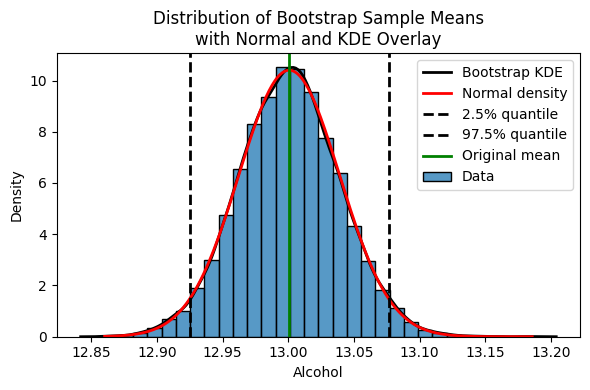

In [44]:
#===============================================================================
# Step 3: Analyse Bootstrap Sample

#---------------
# Sample means
df_sample_mean=df_sample.groupby(['rep']).agg({'alcohol':'mean'}).reset_index()
#---------------

#---------------
# Normal density
x = df_sample_mean['alcohol']
mu = x.mean()
sigma = x.std(ddof=1)
#---------------

#---------------
# CI
ci_low, ci_high = np.percentile(x, [2.5, 97.5])
#---------------

#---------------
# Original mean
orig_mean = df['alcohol'].mean()
#---------------

#---------------
# Plot histogram with KDE
plt.figure(figsize=(6, 4))
sns.histplot(x, bins=30, stat='density', label='Data')

# KDE as a line
sns.kdeplot(x, color='black', lw=2, label='Bootstrap KDE')

# Overlay normal density
xs = np.linspace(x.min(), x.max(), 300)
plt.plot(xs, norm.pdf(xs, mu, sigma), 'r-', lw=2, label='Normal density')

# Confidence interval lines
plt.axvline(ci_low, color='black', linestyle='--', lw=2, label='2.5% quantile')
plt.axvline(ci_high, color='black', linestyle='--', lw=2, label='97.5% quantile')

plt.axvline(orig_mean, color='green', lw=2, label='Original mean')

plt.xlabel('Alcohol')
plt.ylabel('Density')
plt.title('Distribution of Bootstrap Sample Means\nwith Normal and KDE Overlay')
plt.legend()
plt.tight_layout()
plt.show()
#---------------

#===============================================================================
